<a href="https://colab.research.google.com/github/cristhianchr/U-Net-implementation/blob/main/unet_implementation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Reference tutorial:** [Implement and Train U-Net from scratch for Image segmentation - PyTorch](https://www.youtube.com/watch?v=HS3Q_90hnDg)

# **Data loading**

[Data source](https://www.kaggle.com/datasets/ipythonx/carvana-image-masking-png/data)



In [1]:
!pip install -q --upgrade kaggle

from pathlib import Path
import subprocess

dataset_folder = Path("/content/carvana_dataset")
dataset_folder.mkdir(parents=True, exist_ok=True)

subprocess.run([
    "kaggle", "datasets", "download",
    "-d", "ipythonx/carvana-image-masking-png",
    "-p", str(dataset_folder),
    "--unzip"
], check=True)

print(f"\nDataset downloaded in: {dataset_folder}")


Dataset downloaded in: /content/carvana_dataset


In [2]:
base_path = Path("/content/carvana_dataset")
train_images_path = base_path / "train_images"
train_masks_path = base_path / "train_masks"

if train_images_path.exists():
    train_images_path.rename(base_path / "images")
    print("'train_images' was renamed to 'images'")

if train_masks_path.exists():
    train_masks_path.rename(base_path / "masks")
    print("'train_masks' was renamed to 'masks'")

'train_images' was renamed to 'images'
'train_masks' was renamed to 'masks'


Images have the .jpg extension.

Masks have the .png extension.

In [3]:
images_folder = Path("/content/carvana_dataset/images")
masks_folder = Path("/content/carvana_dataset/masks")

In [4]:
image_files = [
    file
    for file in images_folder.iterdir()
    if file.is_file() and file.suffix.lower() == ".jpg"
]

mask_files = [
    file
    for file in masks_folder.iterdir()
    if file.is_file() and file.suffix.lower() == ".png"
]

print(f"Number of JPG images: {len(image_files)}")
print(f"Number of PNG masks: {len(mask_files)}")

if len(image_files) == len(mask_files):
    print("The number of images and masks matches.")
else:
    print("Warning: the number of images and masks does not match.")

Number of JPG images: 5088
Number of PNG masks: 5088
The number of images and masks matches.


### **Data visualization**

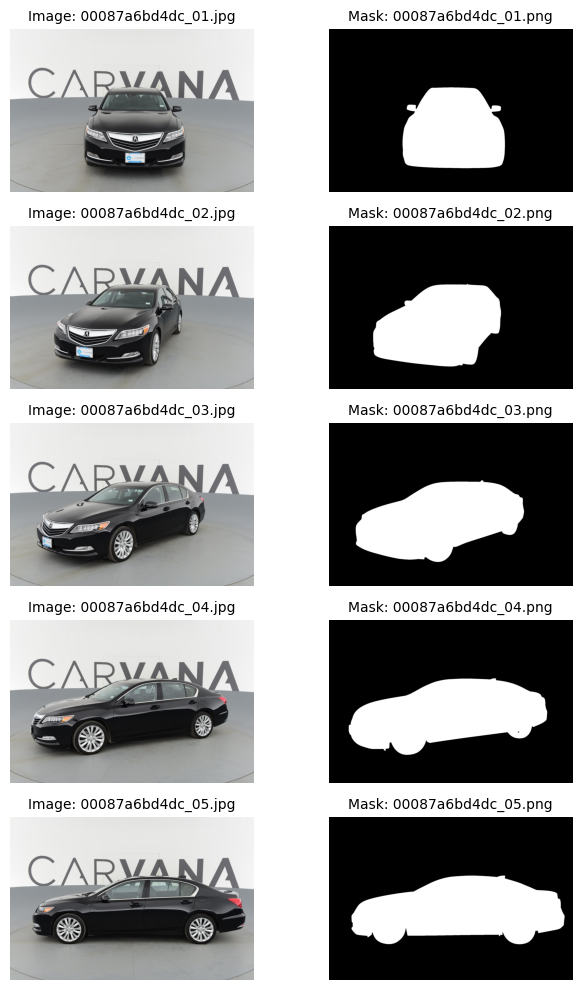

In [5]:
from PIL import Image
import matplotlib.pyplot as plt

image_files = sorted([
    file
    for file in images_folder.iterdir()
    if file.is_file() and file.suffix.lower() == ".jpg"
])

mask_files = {
    file.stem.removesuffix("_mask"): file
    for file in masks_folder.iterdir()
    if file.is_file() and file.suffix.lower() == ".png"
}

image_mask_pairs = []

for image_path in image_files:
    mask_path = mask_files.get(image_path.stem)

    if mask_path is not None:
        image_mask_pairs.append((image_path, mask_path))

    if len(image_mask_pairs) == 5:
        break

if not image_mask_pairs:
    raise ValueError("No matching image and mask pairs were found.")

figure, axes = plt.subplots(
    len(image_mask_pairs),
    2,
    figsize=(7, 2 * len(image_mask_pairs)),
    squeeze=False
)

for row, (image_path, mask_path) in enumerate(image_mask_pairs):
    image = Image.open(image_path).convert("RGB")
    mask = Image.open(mask_path).convert("L")

    axes[row, 0].imshow(image)
    axes[row, 0].set_title(f"Image: {image_path.name}", fontsize=10)
    axes[row, 0].axis("off")

    axes[row, 1].imshow(mask, cmap="gray")
    axes[row, 1].set_title(f"Mask: {mask_path.name}", fontsize=10)
    axes[row, 1].axis("off")

plt.tight_layout()
plt.show()

In [6]:
import numpy as np

image_path = sorted(images_folder.glob("*.jpg"))[0]
mask_path = masks_folder / f"{image_path.stem}.png"

if not mask_path.exists():
    raise FileNotFoundError(f"Matching mask not found: {mask_path}")

image_array = np.array(Image.open(image_path).convert("RGB"))
mask_array = np.array(Image.open(mask_path).convert("L"))

print(f"Image file: {image_path.name}")
print(f"Mask file: {mask_path.name}")

print(f"\nImage shape: {image_array.shape}") # (height, weight, channels)
print(f"Mask shape: {mask_array.shape}")

print(f"\nImage data type: {image_array.dtype}")
print(f"Mask data type: {mask_array.dtype}")

print(f"\nImage height: {image_array.shape[0]}")
print(f"Image width: {image_array.shape[1]}")
print(f"Image channels: {image_array.shape[2]}")

print(f"\nMask height: {mask_array.shape[0]}")
print(f"Mask width: {mask_array.shape[1]}")

Image file: 00087a6bd4dc_01.jpg
Mask file: 00087a6bd4dc_01.png

Image shape: (1280, 1918, 3)
Mask shape: (1280, 1918)

Image data type: uint8
Mask data type: uint8

Image height: 1280
Image width: 1918
Image channels: 3

Mask height: 1280
Mask width: 1918


**Images and masks size**

Images: 1280 (height) x 1918 (width) x 3 (channels)

Masks: 1280 (height) x 1918 (width)

### **Dataset split**


In [7]:
from pathlib import Path
from sklearn.model_selection import train_test_split
import shutil

dataset_root = Path("/content/carvana_dataset")

source_images_folder = dataset_root / "images"
source_masks_folder = dataset_root / "masks"

random_seed = 42
training_ratio = 0.80
validation_ratio = 0.10
test_ratio = 0.10

if not source_images_folder.exists():
    raise FileNotFoundError(f"Images folder not found: {source_images_folder}")

if not source_masks_folder.exists():
    raise FileNotFoundError(f"Masks folder not found: {source_masks_folder}")

image_paths = sorted(source_images_folder.glob("*.jpg"))

mask_paths_by_id = {
    mask_path.stem.removesuffix("_mask"): mask_path
    for mask_path in source_masks_folder.glob("*.png")
}

paired_paths = [
    (image_path, mask_paths_by_id[image_path.stem])
    for image_path in image_paths
    if image_path.stem in mask_paths_by_id
]

if not paired_paths:
    raise ValueError("No matching image and mask pairs were found.")

if len(paired_paths) != len(image_paths):
    raise ValueError("Some images do not have matching masks.")

training_pairs, temporary_pairs = train_test_split(
    paired_paths,
    test_size=validation_ratio + test_ratio,
    random_state=random_seed,
    shuffle=True
)

validation_pairs, test_pairs = train_test_split(
    temporary_pairs,
    test_size=test_ratio / (validation_ratio + test_ratio),
    random_state=random_seed,
    shuffle=True
)

dataset_splits = {
    "train": training_pairs,
    "validation": validation_pairs,
    "test": test_pairs
}

for split_name, split_pairs in dataset_splits.items():
    split_images_folder = dataset_root / split_name / "images"
    split_masks_folder = dataset_root / split_name / "masks"

    split_images_folder.mkdir(parents=True, exist_ok=True)
    split_masks_folder.mkdir(parents=True, exist_ok=True)

    for image_path, mask_path in split_pairs:
        shutil.move(
            str(image_path),
            str(split_images_folder / image_path.name)
        )

        shutil.move(
            str(mask_path),
            str(split_masks_folder / mask_path.name)
        )

source_images_folder.rmdir()
source_masks_folder.rmdir()

print(f"Total pairs: {len(paired_paths)}")
print(f"Train pairs: {len(training_pairs)}")
print(f"Validation pairs: {len(validation_pairs)}")
print(f"Test pairs: {len(test_pairs)}")
print(f"Dataset split completed in: {dataset_root}")

Total pairs: 5088
Train pairs: 4070
Validation pairs: 509
Test pairs: 509
Dataset split completed in: /content/carvana_dataset


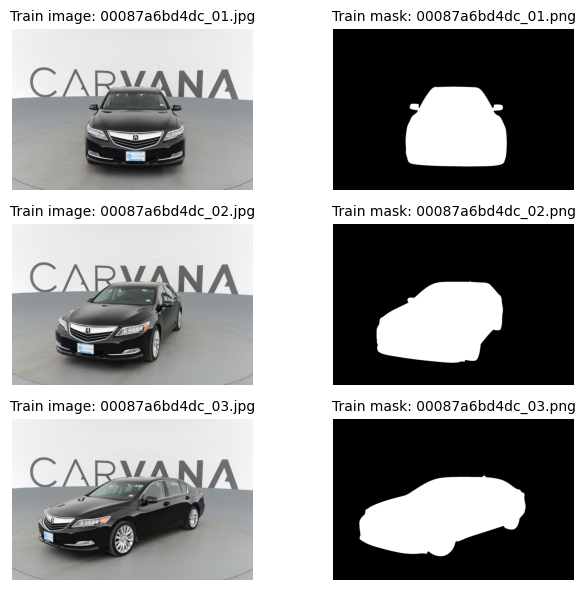

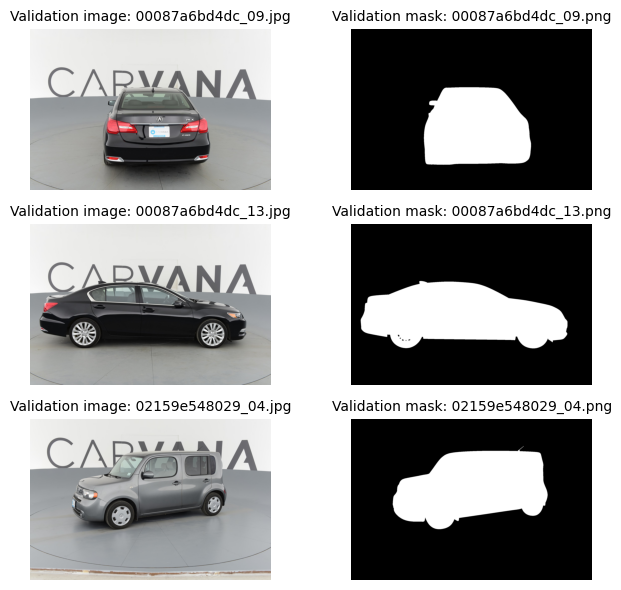

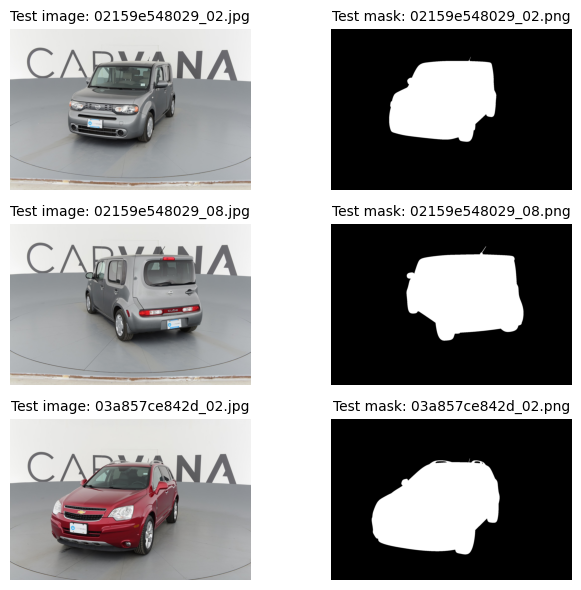

In [8]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

dataset_root = Path("/content/carvana_dataset")
split_names = ["train", "validation", "test"]


def get_image_mask_pairs(split_name, sample_count=3):
    images_folder = dataset_root / split_name / "images"
    masks_folder = dataset_root / split_name / "masks"

    image_paths = sorted(images_folder.glob("*.jpg"))

    mask_paths_by_id = {
        mask_path.stem.removesuffix("_mask"): mask_path
        for mask_path in masks_folder.glob("*.png")
    }

    pairs = [
        (image_path, mask_paths_by_id[image_path.stem])
        for image_path in image_paths
        if image_path.stem in mask_paths_by_id
    ]

    if len(pairs) < sample_count:
        raise ValueError(
            f"Only {len(pairs)} matching pairs found in {split_name}."
        )

    return pairs[:sample_count]


def display_pairs(split_name, pairs):
    figure, axes = plt.subplots(
        len(pairs),
        2,
        figsize=(7, 2 * len(pairs)),
        squeeze=False
    )

    for row, (image_path, mask_path) in enumerate(pairs):
        image = Image.open(image_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")

        axes[row, 0].imshow(image)
        axes[row, 0].set_title(f"{split_name.capitalize()} image: {image_path.name}",
                               fontsize = 10)
        axes[row, 0].axis("off")

        axes[row, 1].imshow(mask, cmap="gray")
        axes[row, 1].set_title(f"{split_name.capitalize()} mask: {mask_path.name}",
                               fontsize = 10)
        axes[row, 1].axis("off")

    plt.tight_layout()
    plt.show()


for split_name in split_names:
    pairs = get_image_mask_pairs(split_name, sample_count=3)
    display_pairs(split_name, pairs)

# **U-Net setup**

In [9]:
import torch
import torch.nn as nn

In [10]:
# Double Convolution class
# Added extra padding = 1 to preserve image dimensions.
# (No padding in original paper)

class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv_op = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv_op(x)

In [11]:
# Down-sampling class
class DownSample(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = DoubleConv(in_channels, out_channels)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

    def forward(self, x):
        down = self.conv(x)
        p = self.pool(down)

        return down, p

In [12]:
# Up-sampling
class UpSample(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_channels, in_channels//2, kernel_size=2, stride=2)
        self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x1, x2):
       x1 = self.up(x1)
       x = torch.cat([x1, x2], 1)
       return self.conv(x)

In [13]:
class UNet(nn.Module):
    def __init__(self, in_channels, num_classes):
        super().__init__()
        self.down_convolution_1 = DownSample(in_channels, 64)
        self.down_convolution_2 = DownSample(64, 128)
        self.down_convolution_3 = DownSample(128, 256)
        self.down_convolution_4 = DownSample(256, 512)

        self.bottle_neck = DoubleConv(512, 1024)

        self.up_convolution_1 = UpSample(1024, 512)
        self.up_convolution_2 = UpSample(512, 256)
        self.up_convolution_3 = UpSample(256, 128)
        self.up_convolution_4 = UpSample(128, 64)

        self.out = nn.Conv2d(in_channels=64, out_channels=num_classes, kernel_size=1)

    def forward(self, x):
       down_1, p1 = self.down_convolution_1(x)
       down_2, p2 = self.down_convolution_2(p1)
       down_3, p3 = self.down_convolution_3(p2)
       down_4, p4 = self.down_convolution_4(p3)

       b = self.bottle_neck(p4)

       up_1 = self.up_convolution_1(b, down_4)
       up_2 = self.up_convolution_2(up_1, down_3)
       up_3 = self.up_convolution_3(up_2, down_2)
       up_4 = self.up_convolution_4(up_3, down_1)

       out = self.out(up_4)
       return out

In [14]:
if __name__ == "__main__":
  double_conv = DoubleConv(256, 256)
  print(double_conv)

  input_image = torch.rand((1, 3, 512, 512))
  model = UNet(3, 10) # 3 channels, 10 classes
  output = model(input_image)
  print(output.size()) # Expected size: [1, 10, 512, 512]

DoubleConv(
  (conv_op): Sequential(
    (0): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
  )
)
torch.Size([1, 10, 512, 512])


# **Dataset**

In [19]:
from pathlib import Path
from PIL import Image

from torch.utils.data import Dataset
from torchvision import transforms
from torchvision.transforms import InterpolationMode


class CarvanaDataset(Dataset):
    def __init__(
        self,
        root_path,
        split="train",
        image_size=(512, 768)
    ):
        self.root_path = Path(root_path)
        self.split = split

        valid_splits = ["train", "validation", "test"]

        if split not in valid_splits:
            raise ValueError(
                f"split must be one of {valid_splits}. Received: {split}"
            )

        images_folder = self.root_path / split / "images"
        masks_folder = self.root_path / split / "masks"

        if not images_folder.exists():
            raise FileNotFoundError(
                f"Images folder not found: {images_folder}"
            )

        if not masks_folder.exists():
            raise FileNotFoundError(
                f"Masks folder not found: {masks_folder}"
            )

        image_paths = sorted(images_folder.glob("*.jpg"))
        mask_paths = sorted(masks_folder.glob("*.png"))

        # Image and mask have the same base filename
        # Example:
        # image: 85bc655a7523_11.jpg
        # mask:  85bc655a7523_11.png
        masks_by_id = {
            mask_path.stem: mask_path
            for mask_path in mask_paths
        }

        self.pairs = [
            (image_path, masks_by_id[image_path.stem])
            for image_path in image_paths
            if image_path.stem in masks_by_id
        ]

        if len(self.pairs) == 0:
            raise ValueError(
                f"No matching image-mask pairs found in split '{split}'."
            )

        if len(self.pairs) != len(image_paths):
            missing_count = len(image_paths) - len(self.pairs)

            print(
                f"Warning: {missing_count} images do not have "
                "a corresponding mask."
            )

        self.image_transform = transforms.Compose([
            transforms.Resize(
                image_size,
                interpolation=InterpolationMode.NEAREST
            ),
            transforms.ToTensor()
        ])

        self.mask_transform = transforms.Compose([
            transforms.Resize(
                image_size,
                interpolation=InterpolationMode.NEAREST
            ),
            transforms.ToTensor()
        ])

    def __getitem__(self, index):
        image_path, mask_path = self.pairs[index]

        image = Image.open(image_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")

        image = self.image_transform(image)
        mask = self.mask_transform(mask)

        # Convert the mask explicitly to binary values: 0 and 1
        mask = (mask > 0).float()

        return image, mask

    def __len__(self):
        return len(self.pairs)

# **Dataset preparation**

In [20]:
import torch
from torch import nn, optim
from torch.utils.data import DataLoader
from tqdm.auto import tqdm


LEARNING_RATE = 1e-4
BATCH_SIZE = 1
EPOCHS = 10

DATA_PATH = "/content/carvana_dataset"
MODEL_SAVE_PATH = "/content/unet.pth"
IMAGE_SIZE = (512, 768)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)


# --------------------------------------------------
# Datasets
# --------------------------------------------------

train_dataset = CarvanaDataset(
    root_path=DATA_PATH,
    split="train",
    image_size=IMAGE_SIZE
)

val_dataset = CarvanaDataset(
    root_path=DATA_PATH,
    split="validation",
    image_size=IMAGE_SIZE
)

print("Train samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))


# --------------------------------------------------
# DataLoaders
# --------------------------------------------------

train_dataloader = DataLoader(
    dataset=train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_dataloader = DataLoader(
    dataset=val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Train batches:", len(train_dataloader))
print("Validation batches:", len(val_dataloader))


# --------------------------------------------------
# Check one batch before training
# --------------------------------------------------

sample_images, sample_masks = next(iter(train_dataloader))

print("Image range:", sample_images.min().item(),
      sample_images.max().item())

print("Mask values:", torch.unique(sample_masks))

print("Foreground ratio:", sample_masks.mean().item())

print(
    "Images finite:",
    torch.isfinite(sample_images).all().item()
)

print(
    "Masks finite:",
    torch.isfinite(sample_masks).all().item()
)


# --------------------------------------------------
# Model, optimizer and loss
# --------------------------------------------------

model = UNet(
    in_channels=3,
    num_classes=1
).to(device)

optimizer = optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE
)

criterion = nn.BCEWithLogitsLoss()


# --------------------------------------------------
# Training
# --------------------------------------------------

for epoch in tqdm(
    range(EPOCHS),
    desc="Training epochs"
):

    model.train()
    train_running_loss = 0.0

    for batch_index, (images, masks) in enumerate(
        tqdm(
            train_dataloader,
            desc=f"Epoch {epoch + 1} - Train",
            leave=False
        )
    ):
        images = images.float().to(device)
        masks = masks.float().to(device)

        optimizer.zero_grad(set_to_none=True)

        predictions = model(images)
        loss = criterion(predictions, masks)

        # Stop immediately if NaN or Inf appears
        if not torch.isfinite(loss):
            print("\nNon-finite loss detected")
            print("Batch:", batch_index)
            print(
                "Images range:",
                images.min().item(),
                images.max().item()
            )
            print(
                "Masks range:",
                masks.min().item(),
                masks.max().item()
            )
            print(
                "Predictions range:",
                predictions.min().item(),
                predictions.max().item()
            )

            raise RuntimeError(
                "Training stopped because loss became NaN or Inf."
            )

        loss.backward()

        # Prevent exploding gradients
        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        train_running_loss += loss.item()

    train_loss = (
        train_running_loss / len(train_dataloader)
    )


    # --------------------------------------------------
    # Validation
    # --------------------------------------------------

    model.eval()
    val_running_loss = 0.0

    with torch.no_grad():

        for images, masks in tqdm(
            val_dataloader,
            desc=f"Epoch {epoch + 1} - Validation",
            leave=False
        ):
            images = images.float().to(device)
            masks = masks.float().to(device)

            predictions = model(images)
            loss = criterion(predictions, masks)

            if not torch.isfinite(loss):
                raise RuntimeError(
                    "Validation loss became NaN or Inf."
                )

            val_running_loss += loss.item()

    val_loss = (
        val_running_loss / len(val_dataloader)
    )

    print("-" * 40)
    print(
        f"Train Loss EPOCH {epoch + 1}: "
        f"{train_loss:.6f}"
    )
    print(
        f"Valid Loss EPOCH {epoch + 1}: "
        f"{val_loss:.6f}"
    )
    print("-" * 40)


# --------------------------------------------------
# Save model
# --------------------------------------------------

torch.save(
    model.state_dict(),
    MODEL_SAVE_PATH
)

print(f"Model saved at: {MODEL_SAVE_PATH}")

Device: cuda
Train samples: 4070
Validation samples: 509
Train batches: 4070
Validation batches: 509
Image range: 0.0 1.0
Mask values: tensor([0., 1.])
Foreground ratio: 0.25099435448646545
Images finite: True
Masks finite: True


Training epochs:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch 1 - Train:   0%|          | 0/4070 [00:00<?, ?it/s]

Epoch 1 - Validation:   0%|          | 0/509 [00:00<?, ?it/s]

----------------------------------------
Train Loss EPOCH 1: 0.059218
Valid Loss EPOCH 1: 0.029695
----------------------------------------
Model saved at: /content/unet.pth


# **Inference**

In [21]:
from pathlib import Path

import torch
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms
from torchvision.transforms import InterpolationMode


def load_model(model_path, device):
    model = UNet(
        in_channels=3,
        num_classes=1
    ).to(device)

    state_dict = torch.load(
        model_path,
        map_location=device
    )

    model.load_state_dict(state_dict)

    # Set the model to inference mode
    model.eval()

    return model


def predict_mask(model, image, device, threshold=0.5):
    """
    Receives an image tensor with shape [3, H, W]
    and returns a binary predicted mask [1, H, W].
    """

    image = image.unsqueeze(0).float().to(device)

    with torch.no_grad():
        logits = model(image)
        probabilities = torch.sigmoid(logits)
        predicted_mask = (probabilities >= threshold).float()

    return predicted_mask.squeeze(0).cpu()


def display_test_predictions(
    data_path,
    model_path,
    device,
    sample_count=3
):
    model = load_model(model_path, device)

    test_dataset = CarvanaDataset(
        root_path=data_path,
        split="test"
    )

    sample_count = min(sample_count, len(test_dataset))

    figure, axes = plt.subplots(
        sample_count,
        3,
        figsize=(12, 4 * sample_count),
        squeeze=False
    )

    for index in range(sample_count):
        image, original_mask = test_dataset[index]

        predicted_mask = predict_mask(
            model=model,
            image=image,
            device=device,
            threshold=0.5
        )

        # Convert image from [C, H, W] to [H, W, C]
        displayed_image = image.permute(1, 2, 0)

        axes[index, 0].imshow(displayed_image)
        axes[index, 0].set_title("Test image")
        axes[index, 0].axis("off")

        axes[index, 1].imshow(
            original_mask.squeeze(0),
            cmap="gray"
        )
        axes[index, 1].set_title("Original mask")
        axes[index, 1].axis("off")

        axes[index, 2].imshow(
            predicted_mask.squeeze(0),
            cmap="gray"
        )
        axes[index, 2].set_title("Predicted mask")
        axes[index, 2].axis("off")

    plt.tight_layout()
    plt.show()


def single_image_inference(
    image_path,
    model_path,
    device,
    threshold=0.5
):
    model = load_model(model_path, device)

    image_transform = transforms.Compose([
        transforms.Resize(
            (512, 768),
            interpolation=InterpolationMode.BILINEAR
        ),
        transforms.ToTensor()
    ])

    original_image = Image.open(image_path).convert("RGB")
    image_tensor = image_transform(original_image)

    predicted_mask = predict_mask(
        model=model,
        image=image_tensor,
        device=device,
        threshold=threshold
    )

    figure, axes = plt.subplots(
        1,
        2,
        figsize=(10, 5)
    )

    axes[0].imshow(image_tensor.permute(1, 2, 0))
    axes[0].set_title("Input image")
    axes[0].axis("off")

    axes[1].imshow(
        predicted_mask.squeeze(0),
        cmap="gray"
    )
    axes[1].set_title("Predicted mask")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()